Dependencies and imports

In [3]:
!pip install -q google-cloud-storage opencv-python numpy matplotlib


print("✓ Dependencies installed")

import numpy as np
import os
import cv2
import gzip
import json
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Optional, Generator, Tuple, List
from google.cloud import storage
from google.auth.credentials import AnonymousCredentials
from concurrent.futures import ThreadPoolExecutor

print("✓ Imports ready")

✓ Dependencies installed
✓ Imports ready


Caching system

In [4]:
CACHE_FILE = "processed_frames.json"

def load_processed():
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE) as f:
            return json.load(f)
    return {}

def save_processed(data):
    with open(CACHE_FILE, "w") as f:
        json.dump(data, f)

processed_cache = load_processed()

print("✓ Processed frame cache ready")

✓ Processed frame cache ready


Frame dataclass

In [5]:
@dataclass
class Frame:
    frame_id: int
    timestamp: float
    rgb: np.ndarray
    depth: np.ndarray
    session_id: str
    camera: str
    view: str
    fps: int
    resolution: Tuple[int, int]

SANPO Loader

In [6]:
class SANPOLoader:

    def __init__(self,
                 sanpo_root="gs://gresearch/sanpo_dataset/v0/sanpo-real",
                 camera="chest",
                 view="left"):

        self.sanpo_root = sanpo_root.rstrip("/")
        self.camera = camera
        self.view = view

        credentials = AnonymousCredentials()
        self.client = storage.Client(credentials=credentials, project='gresearch')

        parts = self.sanpo_root.split("/")
        self.bucket_name = parts[2]
        self.prefix = "/".join(parts[3:])

        self.bucket = self.client.bucket(self.bucket_name)

        self.session_cache = None

    # -------------------------
    # SESSION LISTING (cached)
    # -------------------------
    def list_sessions(self):

        if self.session_cache is not None:
            return self.session_cache

        prefix = f"{self.prefix}/"
        blobs = self.bucket.list_blobs(prefix=prefix)

        sessions = set()

        for blob in blobs:
            parts = blob.name[len(prefix):].split("/")
            if len(parts) > 1:
                sessions.add(parts[0])

        self.session_cache = sorted(list(sessions))
        return self.session_cache

    # -------------------------
    # METADATA
    # -------------------------
    def get_session_metadata(self, session_id):

        path = f"{self.prefix}/{session_id}/description.json"
        blob = self.bucket.blob(path)

        try:
            return json.loads(blob.download_as_string())
        except:
            return {}

    # -------------------------
    # RGB LOADER
    # -------------------------
    def _get_rgb(self, session_id, frame_id):

        path = f"{self.prefix}/{session_id}/camera_{self.camera}/{self.view}/video_frames/{frame_id:06d}.png"

        try:
            blob = self.bucket.blob(path)
            arr = np.frombuffer(blob.download_as_bytes(), np.uint8)
            img = cv2.imdecode(arr, cv2.IMREAD_COLOR)

            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        except:
            return None

    # -------------------------
    # DEPTH LOADER
    # -------------------------
    def _get_depth(self, session_id, frame_id):

        path = f"{self.prefix}/{session_id}/camera_{self.camera}/{self.view}/depth_maps/{frame_id:06d}.float16.gz"

        try:
            blob = self.bucket.blob(path)
            raw = gzip.decompress(blob.download_as_bytes())

            depth = np.frombuffer(raw, dtype=np.float16)

            expected = 720 * 1280

            if len(depth) > expected:
                depth = depth[:expected]

            if len(depth) != expected:
                return None

            depth = depth.reshape(720, 1280).astype(np.float32)

            # remove invalid depth values
            depth[depth > 100] = 0

            return depth

        except:
            return None

    # -------------------------
    # FRAME ITERATOR
    # -------------------------



    def _load_frame_pair(self, session_id, frame_id, fps):

        rgb = self._get_rgb(session_id, frame_id)
        depth = self._get_depth(session_id, frame_id)

        if rgb is None or depth is None:
            return None

        return Frame(
            frame_id=frame_id,
            timestamp=frame_id / fps,
            rgb=rgb,
            depth=depth,
            session_id=session_id,
            camera=self.camera,
            view=self.view,
            fps=fps,
            resolution=(rgb.shape[1], rgb.shape[0])
        )


    def iter_frames(self, session_id, max_frames=5, workers=6):

        meta = self.get_session_metadata(session_id)
        fps = meta.get("fps", 15)

        if session_id not in processed_cache:
            processed_cache[session_id] = []

        frame_ids = [i for i in range(max_frames) if i not in processed_cache[session_id]]

        with ThreadPoolExecutor(max_workers=workers) as executor:

            futures = [
                executor.submit(self._load_frame_pair, session_id, fid, fps)
                for fid in frame_ids
            ]

            for fid, future in zip(frame_ids, futures):

                frame = future.result()

                if frame is None:
                    continue

                processed_cache[session_id].append(fid)
                save_processed(processed_cache)

                yield frame


Loader initialisation

In [7]:
loader = SANPOLoader()

sessions = loader.list_sessions()

assert len(sessions) > 0, "❌ No sessions found!"

print(f"✓ Found {len(sessions)} sessions")
print("Sample sessions:", sessions[:5])

✓ Found 702 sessions
Sample sessions: ['-5OCPnbrwJdu3jH70ieU7pUiFsOJQoeG', '-F9N8JhMuJZmOpz2M8o1At2j-jAas9AA', '-MnIHGYpsPvn4CF_iAKGfRQewKSEZGv1', '-PXxwecxoR8mWhFQ09j-lddcSMLO_0K2', '-PqSDmiEe2pXjmYHgxh4YEBsj0T5LU10']


Load metadata

In [8]:
session_id = sessions[0]

meta = loader.get_session_metadata(session_id)

print("✓ Metadata loaded:")
print(json.dumps(meta, indent=2)[:500])

✓ Metadata loaded:
{
  "session_type": "real",
  "session_video_metadata": {
    "human_traffic": "HUMAN_TRAFFIC_MODERATE",
    "vehicular_traffic": "VEHICULAR_TRAFFIC_HEAVY",
    "animal_traffic": "ANIMAL_TRAFFIC_LOW",
    "num_obstacles": "NUM_OBSTACLES_MEDIUM",
    "environment_types": [
      "ENVIRONMENT_TYPE_URBAN",
      "ENVIRONMENT_TYPE_ROAD_JUNCTION"
    ],
    "weather_conditions": [
      "WEATHER_CONDITION_SUNNY"
    ],
    "visibility": "VISIBILITY_HIGH",
    "ego_motion": "EGO_MOTION_WALKING",
    "


Load frames

In [9]:
frames = list(loader.iter_frames(session_id, max_frames=5))

assert len(frames) > 0, "❌ No frames loaded!"

print(f"✓ Loaded {len(frames)} frames")

for i, f in enumerate(frames):

    assert f.rgb.shape[2] == 3
    assert len(f.depth.shape) == 2

    print(
        f"Frame {i}: RGB {f.rgb.shape}, Depth {f.depth.shape}, "
        f"Range [{f.depth.min():.2f}, {f.depth.max():.2f}] m"
    )

✓ Loaded 5 frames
Frame 0: RGB (1242, 2208, 3), Depth (720, 1280), Range [0.00, 33.34] m
Frame 1: RGB (1242, 2208, 3), Depth (720, 1280), Range [0.00, 11.62] m
Frame 2: RGB (1242, 2208, 3), Depth (720, 1280), Range [0.00, 7.75] m
Frame 3: RGB (1242, 2208, 3), Depth (720, 1280), Range [0.00, 12.70] m
Frame 4: RGB (1242, 2208, 3), Depth (720, 1280), Range [0.00, 15.99] m


Depth sanity check

In [10]:
all_depths = np.concatenate([f.depth.flatten() for f in frames])

print("Min:", np.min(all_depths))
print("Max:", np.max(all_depths))
print("Mean:", np.mean(all_depths))

valid_depths = all_depths[all_depths > 0]

assert len(valid_depths) > 0
assert np.min(valid_depths) >= 0
assert np.max(valid_depths) < 50

print("✓ Depth values valid")

Min: 0.0
Max: 33.34375
Mean: 3.3972578
✓ Depth values valid


Visualise

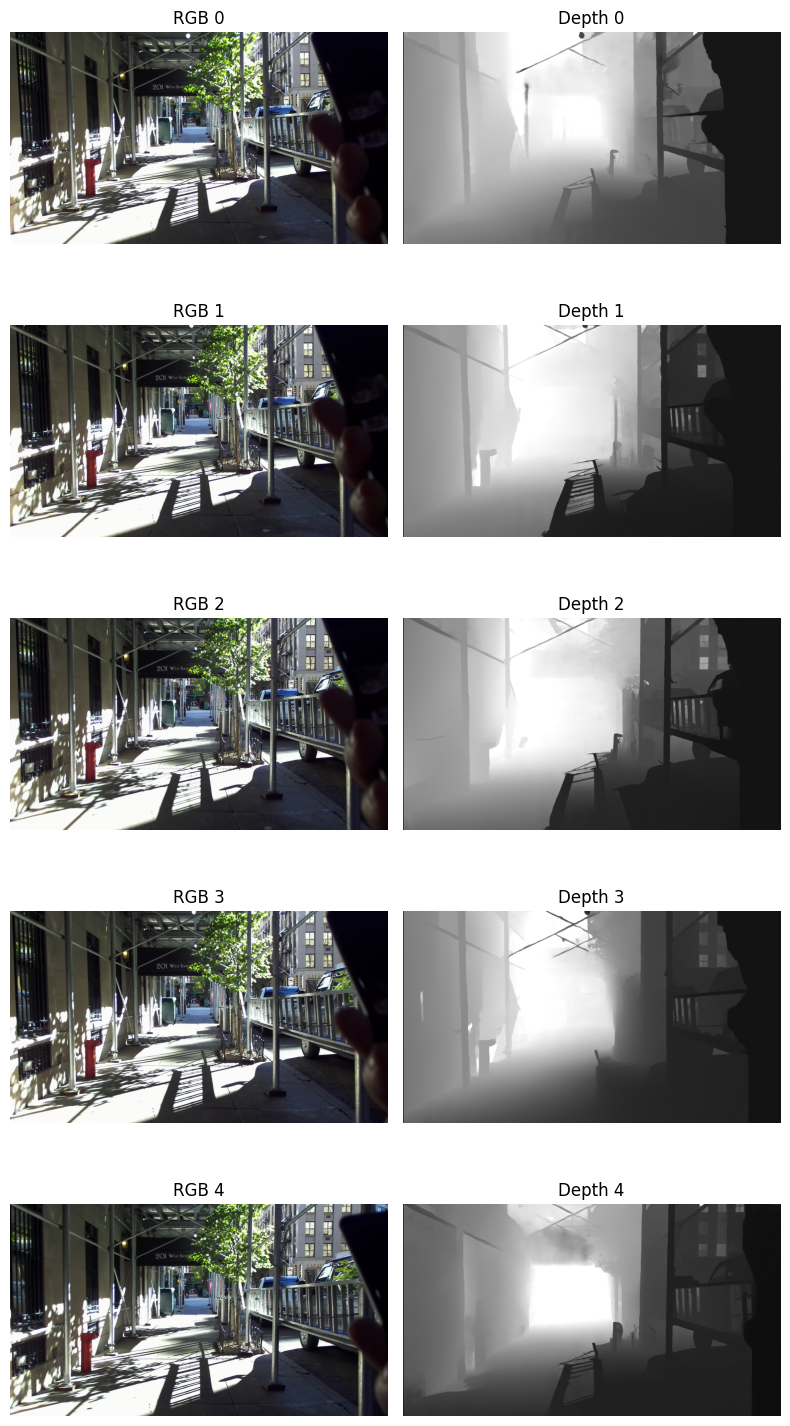

In [11]:
fig, axes = plt.subplots(len(frames), 2, figsize=(8, 3*len(frames)))

for i, f in enumerate(frames):

    axes[i,0].imshow(f.rgb)
    axes[i,0].set_title(f"RGB {i}")
    axes[i,0].axis("off")

    depth_vis = np.clip(f.depth, 0, np.percentile(f.depth, 95))

    axes[i,1].imshow(depth_vis, cmap="gray")
    axes[i,1].set_title(f"Depth {i}")
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()

## Composite Perception Engine: Stream Pipeline
The following cells will link this loader directly into your perception pipeline in memory, processing and outputting the K-Threat Fact Sheets instantly!

In [ ]:
# 1. Setup your Colab environment
from google.colab import drive
drive.mount('/content/drive')

!git clone -b dataset https://github.com/PES-112/CompositePerceptionEngine.git /content/CPE
%cd /content/CPE
!pip install -q ultralytics lapx


In [ ]:
# 2. Import your Stream Pipeline
import sys
from pathlib import Path

sys.path.append('/content/CPE')
from src.perception_stack.stream_pipeline import run_stream_session


In [ ]:
# 3. Run the Stream Pipeline on 5 sessions!
out_jsonl = Path("/content/train.jsonl")

for session_id in sessions[:5]:
    print(f"\n=== Processing Session: {session_id} ===")
    
    # Max 300 frames to start, you can increase this later
    frame_generator = loader.iter_frames(session_id, max_frames=300)
    
    written, skipped = run_stream_session(
        frame_generator=frame_generator,
        fps=15.0,
        out_jsonl_path=out_jsonl,
        lookahead_s=2.0
    )
    
# Save your massive dataset to Google Drive so Colab doesn't wipe it!
!cp /content/train.jsonl "/content/drive/My Drive/train.jsonl"
print("\nAll sessions finished and saved safely!")
